In [12]:
!pip install prophet

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('online_retail_sales_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [16]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_sales.columns = ['ds', 'y']

In [17]:
daily_sales.head()

,ds,y
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


In [18]:
from prophet import Prophet

In [19]:
model = Prophet()

In [20]:
model.fit(daily_sales)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [21]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

In [22]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
684,2012-02-28,28873.580954,12874.466973,44076.014663
685,2012-02-29,25950.788443,9776.135359,41863.474954
686,2012-03-01,32761.051901,17507.734473,49039.503604
687,2012-03-02,22663.906619,6152.692714,39071.292065
688,2012-03-03,-18126.458253,-34267.089712,-1667.730240
689,2012-03-04,12476.288348,-3110.327348,29421.166203
690,2012-03-05,23585.686088,8497.964661,40035.658148
691,2012-03-06,25993.197184,10493.273789,42854.795722
692,2012-03-07,23062.276256,8648.719332,40285.504105
693,2012-03-08,29985.164436,13465.782398,45604.406032


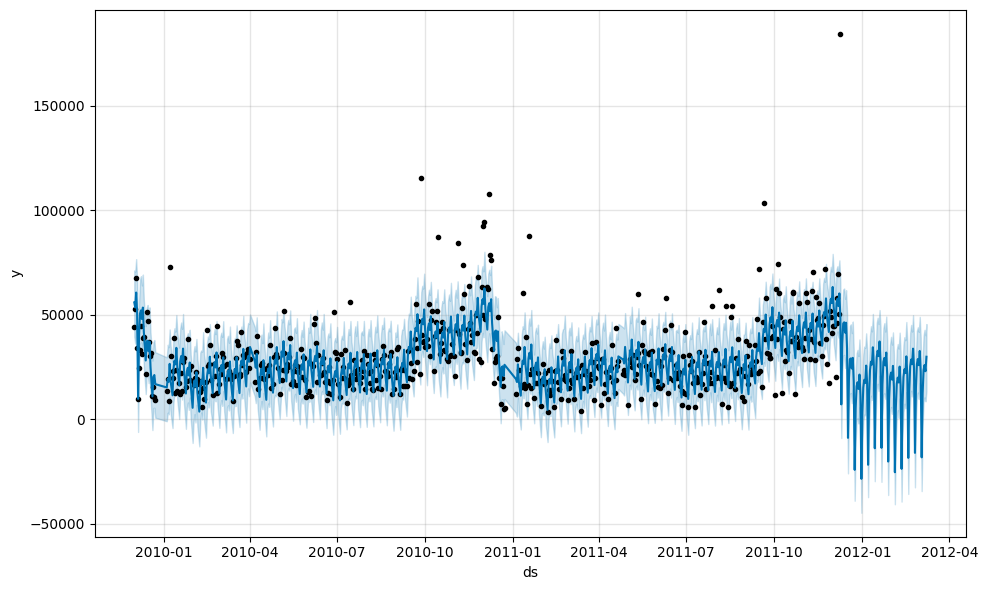

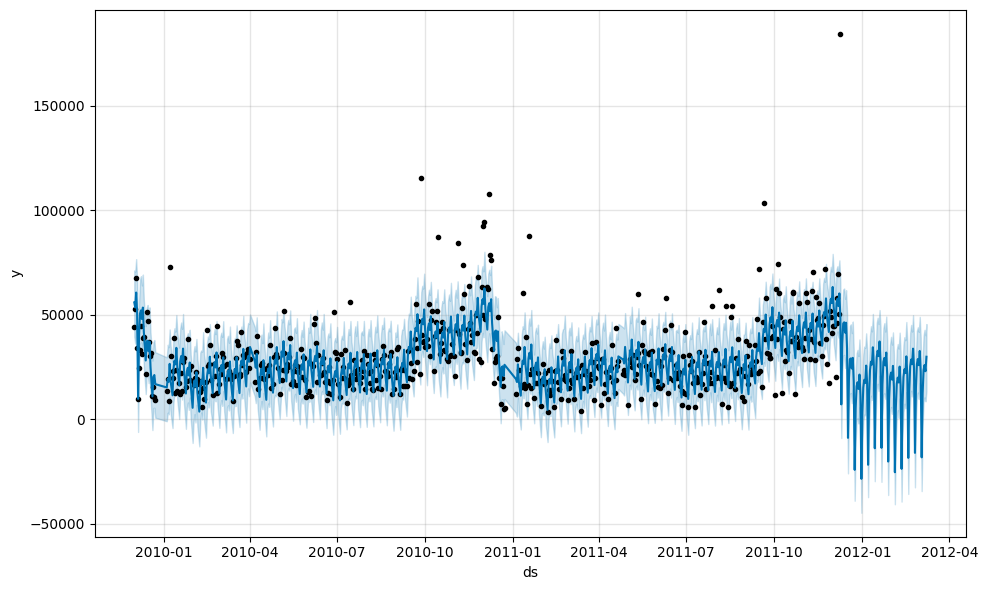

In [23]:
model.plot(forecast)

In [24]:
forecast['yhat'] = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)

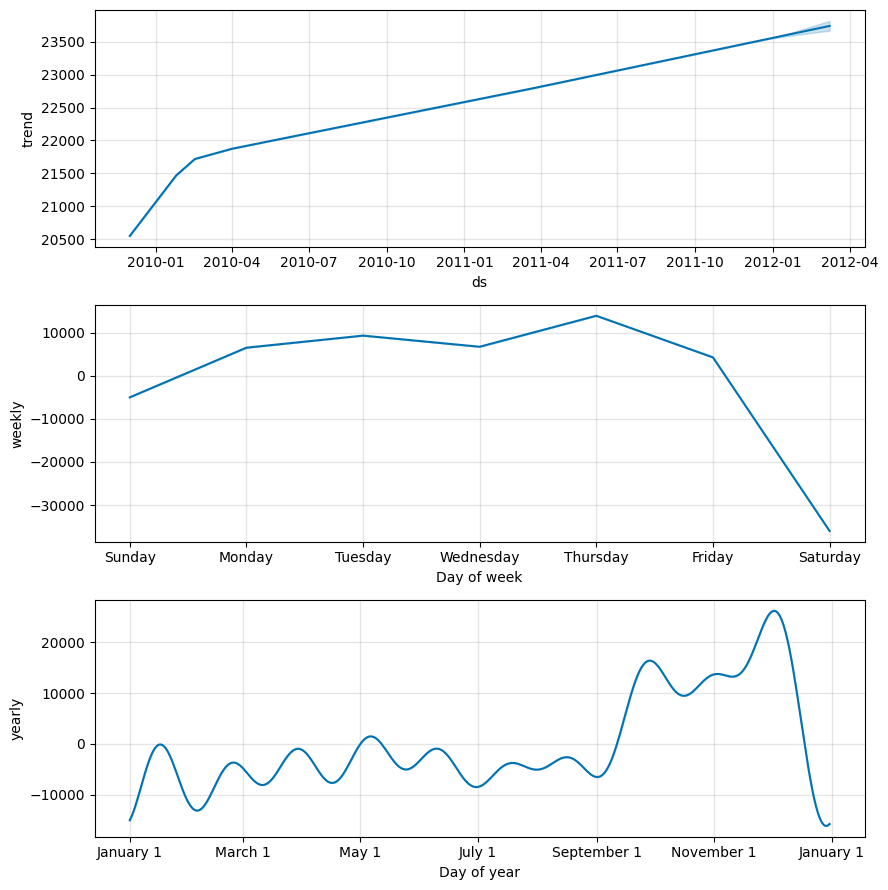

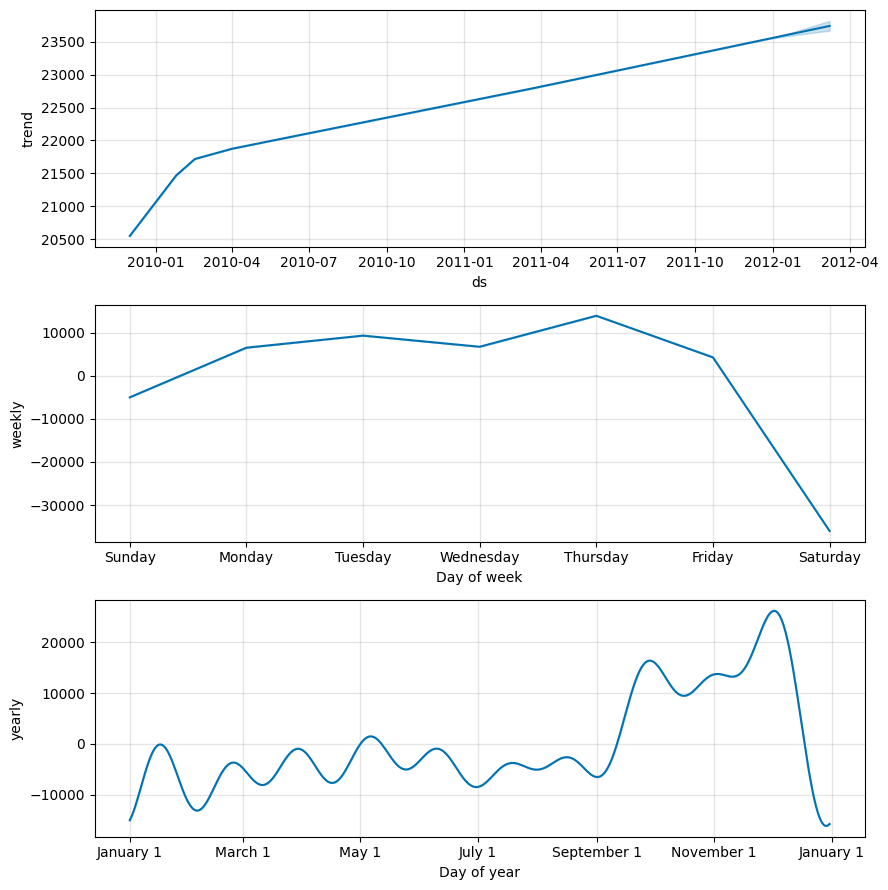

In [25]:
model.plot_components(forecast)

In [26]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('ales_forecast.csv', index=False)